# Tiled Scoring Workflow Demo


## About the demo data

This notebook runs a multitile scoring workflow using the combined setup CSV and `batch_config.json`, then inspects tile-specific outputs.


## Prerequisites

This notebook assumes `sortscore` is installed and available in the same Python environment as the Jupyter kernel.

Recommended setup (outside this notebook, in terminal from repository root):
```bash
python -m venv .venv
source .venv/bin/activate
pip install -e .
pip install ipykernel
python -m ipykernel install --user --name=sortscore-venv --display-name="Python (sortscore venv)"
```

After setup, select that kernel for this notebook.

In [1]:
import importlib.util
import shutil

cli_path = shutil.which("sortscore")
pkg_ok = importlib.util.find_spec("sortscore") is not None

if cli_path or pkg_ok:
    print("sortscore is installed in this environment.")
    if cli_path:
        print(f"CLI path: {cli_path}")
else:
    print("sortscore is not installed in this environment.")
    print("See installation guide: docs/installation.md")

sortscore is installed in this environment.
CLI path: /Users/c.chitwood/code/sortscore/venv/bin/sortscore


## 1) Set run inputs


In [2]:
from pathlib import Path
import sys

EXPERIMENT_NAME = "test_multitile_regression"
TARGET_TILE = 2
EXPERIMENT_SETUP_PATH = "demo_data/combined_experiment_setup.csv"
CONFIG_PATH = "demo_data/batch_config.json"

def resolve_path(path_str):
    path = Path(path_str)
    candidates = [path, Path("..") / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return path

EXPERIMENT_SETUP_FILE = resolve_path(EXPERIMENT_SETUP_PATH)
CONFIG_FILE = resolve_path(CONFIG_PATH)

print(f"experiment_setup: {EXPERIMENT_SETUP_FILE}")
print(f"config: {CONFIG_FILE}")
print(f"target_tile: {TARGET_TILE}")


experiment_setup: /Users/c.chitwood/code/sortscore/demo_data/combined_experiment_setup.csv
config: /Users/c.chitwood/code/sortscore/demo_data/batch_config.json
target_tile: 2


## 2) Run tile scoring workflow
If sortscore has been pip installed in the environment, this snippet will use the `sortscore score` subcommand directly in the CLI. If not, it will run as a module. Behavior and outputs are the same in either case.

In [3]:
import shutil
import subprocess
def supports_subcommands() -> bool:
    if not shutil.which("sortscore"):
        return False
    proc = subprocess.run(["sortscore", "--help"], capture_output=True, text=True)
    help_text = (proc.stdout or "") + "\n" + (proc.stderr or "")
    return "<score|norm>" in help_text or "sortscore <score|norm>" in help_text

In [4]:
import sys

if supports_subcommands():
    score_cmd = f"sortscore score -n {EXPERIMENT_NAME} -e {EXPERIMENT_SETUP_FILE} -c {CONFIG_FILE}"
else:
    score_cmd = f"{sys.executable} -m sortscore score -n {EXPERIMENT_NAME} -e {EXPERIMENT_SETUP_FILE} -c {CONFIG_FILE}"

print(score_cmd)
!{score_cmd}


sortscore score -n test_multitile_regression -e /Users/c.chitwood/code/sortscore/demo_data/combined_experiment_setup.csv -c /Users/c.chitwood/code/sortscore/demo_data/batch_config.json
INFO:root:Using date-based output suffix: 20260305
INFO:root:Detected 2 tiles. Running scoring independently per tile using one shared setup file.
INFO:root:Running tile 1: output_dir=_test_outputs/multitile_output/tile1
INFO:root:Using mutagenesis_type: 'codon'
INFO:root:Loaded counts for 3 replicates.
Counts loaded.
INFO:sortscore.utils.analysis_logger:Analysis logger initialized: test_multitile_regression_tile1_20260305_20260305_012653
INFO:root:Using mutagenesis_type: 'codon'
INFO:root:Processing DNA workflow
INFO:root:Calculated DNA scores for 2081 variants.
INFO:root:Saved DNA scores to /Users/c.chitwood/code/sortscore/demo_data/_test_outputs/multitile_output/tile1/scores/test_multitile_regression_tile1_dna_scores_20260305.csv
INFO:sortscore.utils.analysis_logger:Logged output file: dna_scores -> t

## 3) Run across-tile normalization workflow


In [5]:
if supports_subcommands():
    norm_cmd = f"sortscore norm -c {CONFIG_FILE}"
else:
    norm_cmd = f"{sys.executable} -m sortscore norm -c {CONFIG_FILE}"

print(norm_cmd)
!{norm_cmd}


sortscore norm -c /Users/c.chitwood/code/sortscore/demo_data/batch_config.json
INFO:root:Loaded batch config with 2 tiles
INFO:sortscore.analysis.batch_normalization:Starting batch normalization workflow
INFO:sortscore.analysis.batch_normalization:Loaded batch config entry 1: tile=1, output_dir=/Users/c.chitwood/code/sortscore/demo_data/_test_outputs/multitile_output/tile1
INFO:sortscore.analysis.batch_normalization:Loaded batch config entry 2: tile=2, output_dir=/Users/c.chitwood/code/sortscore/demo_data/_test_outputs/multitile_output/tile2
INFO:sortscore.analysis.batch_normalization:Combined 4162 variants from 2 experiments
INFO:sortscore.analysis.batch_normalization:Applying z-score scaled 2-pole normalization
INFO:sortscore.analysis.batch_normalization:Z-score 2-pole normalization complete
INFO:sortscore.analysis.batch_normalization:Applied zscore_2pole normalization to 4162 variants
INFO:root:Batch analysis complete using zscore_2pole normalization
INFO:sortscore.analysis.batch_no

## 4) Resolve tile and batch output files


In [6]:
import json
import pandas as pd
from IPython.display import Image, Markdown, display

with open(CONFIG_FILE, "r", encoding="utf-8") as f:
    config = json.load(f)

tile_entry = next((e for e in config.get("experiments", []) if int(e.get("tile", -1)) == int(TARGET_TILE)), None)
tile_experiment_name = f"{EXPERIMENT_NAME}_tile{TARGET_TILE}"

if tile_entry is None:
    print(f"No tile entry found for tile={TARGET_TILE} in batch config.")
    scores_dir = None
    figures_dir = None
    stats_file = None
    aa_scores_file = None
    dna_scores_file = None
    aa_heatmap_file = None
    codon_heatmap_file = None
else:
    output_dir_cfg = Path(tile_entry.get("output_dir", "output"))
    if output_dir_cfg.is_absolute():
        output_dir = output_dir_cfg
    else:
        output_dir = (CONFIG_FILE.parent / output_dir_cfg).resolve()

    scores_dir = output_dir / "scores"
    figures_dir = output_dir / "figures"

    def newest(base_dir, pattern):
        files = [p for p in base_dir.glob(pattern) if p.is_file() and p.name.startswith(f"{tile_experiment_name}_")]
        return max(files, key=lambda p: p.stat().st_mtime) if files else None

    stats_file = newest(scores_dir, f"{tile_experiment_name}_aa_stats_*.json") or newest(scores_dir, f"{tile_experiment_name}_dna_stats_*.json")
    aa_scores_file = newest(scores_dir, f"{tile_experiment_name}_aa_scores_*.csv")
    dna_scores_file = newest(scores_dir, f"{tile_experiment_name}_dna_scores_*.csv")
    aa_heatmap_file = newest(figures_dir, f"{tile_experiment_name}_aa_heatmap_*.png")
    codon_heatmap_file = newest(figures_dir, f"{tile_experiment_name}_codon_heatmap_*.png")

combined_output_cfg = Path(config.get("combined_output_dir", "normalized"))
if combined_output_cfg.is_absolute():
    combined_output_dir = combined_output_cfg
else:
    combined_output_dir = (CONFIG_FILE.parent / combined_output_cfg).resolve()

batch_scores_dir = combined_output_dir / "scores"
batch_figures_dir = combined_output_dir / "figures"

def newest_any(base_dir, pattern):
    files = [p for p in base_dir.glob(pattern) if p.is_file()]
    return max(files, key=lambda p: p.stat().st_mtime) if files else None

batch_stats_file = newest_any(batch_scores_dir, "batch_stats_*.json")
batch_scores_file = newest_any(batch_scores_dir, "batch_scores_*.csv")
tiled_heatmap_file = newest_any(batch_figures_dir, "tiled_heatmap_*.png")
combined_aa_heatmap_file = newest_any(batch_figures_dir, "combined_aa_heatmap_*.png")


## 5) Print tile and batch stats JSON


In [7]:
if stats_file is None:
    print("No tile stats JSON found for this experiment name.")
else:
    display(Markdown(f"### Tile stats (`{stats_file.name}`)"))
    with open(stats_file, "r", encoding="utf-8") as f:
        stats = json.load(f)
    print(json.dumps(stats, indent=2))

if batch_stats_file is None:
    print("No batch stats JSON found in combined output.")
else:
    display(Markdown(f"### Batch stats (`{batch_stats_file.name}`)"))
    with open(batch_stats_file, "r", encoding="utf-8") as f:
        batch_stats = json.load(f)
    print(json.dumps(batch_stats, indent=2))


### Tile stats (`test_multitile_regression_tile2_aa_stats_20260305.json`)

{
  "all_avg": 1236,
  "all_min": 219,
  "all_max": 2344,
  "syn_avg": 1499,
  "syn_min": 1499,
  "syn_max": 1499,
  "nonsense_avg": 293,
  "nonsense_min": 219,
  "nonsense_max": 427,
  "missense_avg": 1285,
  "missense_min": 302,
  "missense_max": 2344
}


### Batch stats (`batch_stats_batch_zscore_2pole_20260305.json`)

{
  "wt_dna_score_global_raw": 1780.0,
  "syn_mean_global_zscore": 1784.7604978079808,
  "syn_std_global_zscore": 467.4910467806795,
  "non_avg_global_zscore_z": -2.9456752452829926,
  "normalization_method": "zscore_2pole",
  "pathogenic_control_type": "nonsense",
  "wt_dna_score_experiment1_raw": 2070.0,
  "normalization_factor_wt_experiment1": 0.8599033816425121,
  "wt_dna_score_experiment2_raw": 1485.0,
  "normalization_factor_wt_experiment2": 1.1986531986531987,
  "non_avg_experiment1_zscore_z": -2.825692491308505,
  "normalization_factor_path_experiment1": 1.0424613627786958,
  "non_avg_experiment2_zscore_z": -3.06565799925748,
  "normalization_factor_path_experiment2": 0.960862316017133,
  "all_avg_global_final": -0.7899723255174279,
  "all_min_global_final": -3.6270284084698665,
  "all_max_global_final": 2.986030436201666,
  "all_avg_experiment1_final": -0.9790619786039267,
  "missense_avg_experiment1_final": -0.910773491353611,
  "nonsense_avg_experiment1_final": -2.9456752452

## 6) Show tile and batch score table heads


In [8]:
if aa_scores_file is None:
    print("No amino-acid scores CSV found for this tile.")
else:
    display(Markdown(f"### Tile amino-acid scores (`{aa_scores_file.name}`)"))
    display(pd.read_csv(aa_scores_file).head())

if dna_scores_file is None:
    print("No DNA/codon scores CSV found for this tile.")
else:
    display(Markdown(f"### Tile DNA/codon scores (`{dna_scores_file.name}`)"))
    display(pd.read_csv(dna_scores_file).head())

if batch_scores_file is None:
    print("No batch-normalized scores CSV found in combined output.")
else:
    display(Markdown(f"### Batch-normalized scores (`{batch_scores_file.name}`)"))
    display(pd.read_csv(batch_scores_file).head())


### Tile amino-acid scores (`test_multitile_regression_tile2_aa_scores_20260305.csv`)

,aa_seq_diff,annotate_aa,avgscore,avgscore_rep_weighted,Rep1.score,Rep2.score,Rep3.score,SD_rep,CV_rep,n_measurements,SEM,CI_lower,CI_upper
0,A.26.*,nonsense,287,287,291,304,267,19,0.065,3,11,241,334
1,A.26.C,missense_aa,932,940,964,1056,776,143,0.153,3,82,578,1286
2,A.26.D,missense_aa,1852,1818,1933,1642,1981,183,0.099,3,106,1397,2307
3,A.26.E,missense_aa,1268,1265,1232,1239,1331,55,0.044,3,32,1130,1405
4,A.26.F,missense_aa,1373,1381,1372,1410,1338,36,0.026,3,21,1284,1463


### Tile DNA/codon scores (`test_multitile_regression_tile2_dna_scores_20260305.csv`)

,variant_seq,count.r1b1,count.r1b2,count.r1b3,count.r1b4,count.r2b1,count.r2b2,count.r2b3,count.r2b4,count.r3b1,...,dna_seq_diff,aa_seq,aa_seq_diff,annotate_dna,annotate_aa,SD_rep,CV_rep,n_measurements,CI_lower,CI_upper
0,AAACCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,8195.0,24167.0,53644,103224.0,14899.0,30223.0,54252,102591.0,12987.0,...,"T.2.A, C.3.A",KPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.K,missense_dna,missense_aa,118,0.059,3,1690,2275
1,AACCCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,4441.0,8140.0,22312,50827.0,4012.0,12954.0,15015,71474.0,1744.0,...,T.2.A,NPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.N,missense_dna,missense_aa,224,0.102,3,1644,2756
2,AAGCCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,8438.0,6493.0,16931,26424.0,5834.0,13288.0,18054,36365.0,4440.0,...,"T.2.A, C.3.G",KPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.K,missense_dna,missense_aa,20,0.011,3,1810,1908
3,AATCCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,50567.0,83151.0,98158,98984.0,69898.0,104548.0,81567,127937.0,53167.0,...,"T.2.A, C.3.T",NPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.N,missense_dna,missense_aa,82,0.062,3,1113,1520
4,ACACCTGGCTGCACCAAGAGATACACCGACCCTAGCAGCCTGAGGA...,98.0,145.0,40,213.0,113.0,272.0,129,92.0,3.0,...,"T.2.C, C.3.A",TPGCTKRYTDPSSLRKHVKTVHGPDAHVTKKQR,I.1.T,missense_dna,missense_aa,657,0.435,3,-123,3139


### Batch-normalized scores (`batch_scores_batch_zscore_2pole_20260305.csv`)

,variant_seq,count.r1b1,count.r1b2,count.r1b3,count.r1b4,count.r2b1,count.r2b2,count.r2b3,count.r2b4,count.r3b1,...,aa_seq,aa_seq_diff,annotate_dna,annotate_aa,SD_rep,CV_rep,n_measurements,CI_lower,CI_upper,batch
0,AAAGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,5.0,2.0,270.0,0.0,3.0,6.0,2.0,1.0,7.0,...,KEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.K,missense_dna,missense_aa,157.0,0.241,3,262.0,1044.0,experiment1
1,AACGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,288.0,4.0,4.0,0.0,9.0,6.0,3.0,0.0,8.0,...,NEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.N,missense_dna,missense_aa,93.0,0.326,3,54.0,515.0,experiment1
2,AAGGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,6411.0,11263.0,7266.0,848.0,10701.0,13868.0,14046.0,1815.0,13450.0,...,KEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.K,missense_dna,missense_aa,153.0,0.235,3,273.0,1035.0,experiment1
3,AATGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,78513.0,87202.0,30286.0,7313.0,77444.0,95087.0,55511.0,8499.0,79605.0,...,NEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.N,missense_dna,missense_aa,70.0,0.137,3,337.0,683.0,experiment1
4,ACAGAGCACGAGGGCTGCAACAAGGCCTTCAGCAACGCCAGCGACA...,0.0,0.0,0.0,33.0,0.0,1.0,1.0,0.0,51.0,...,TEHEGCNKAFSNASDRAKHQNRTHSNEKPYICK,C.1.T,missense_dna,missense_aa,1373.0,1.076,3,-2134.0,4686.0,experiment1


## 7) Show tile and batch visualizations


### Tile codon heatmap (`test_multitile_regression_tile2_codon_heatmap_20260305.png`)

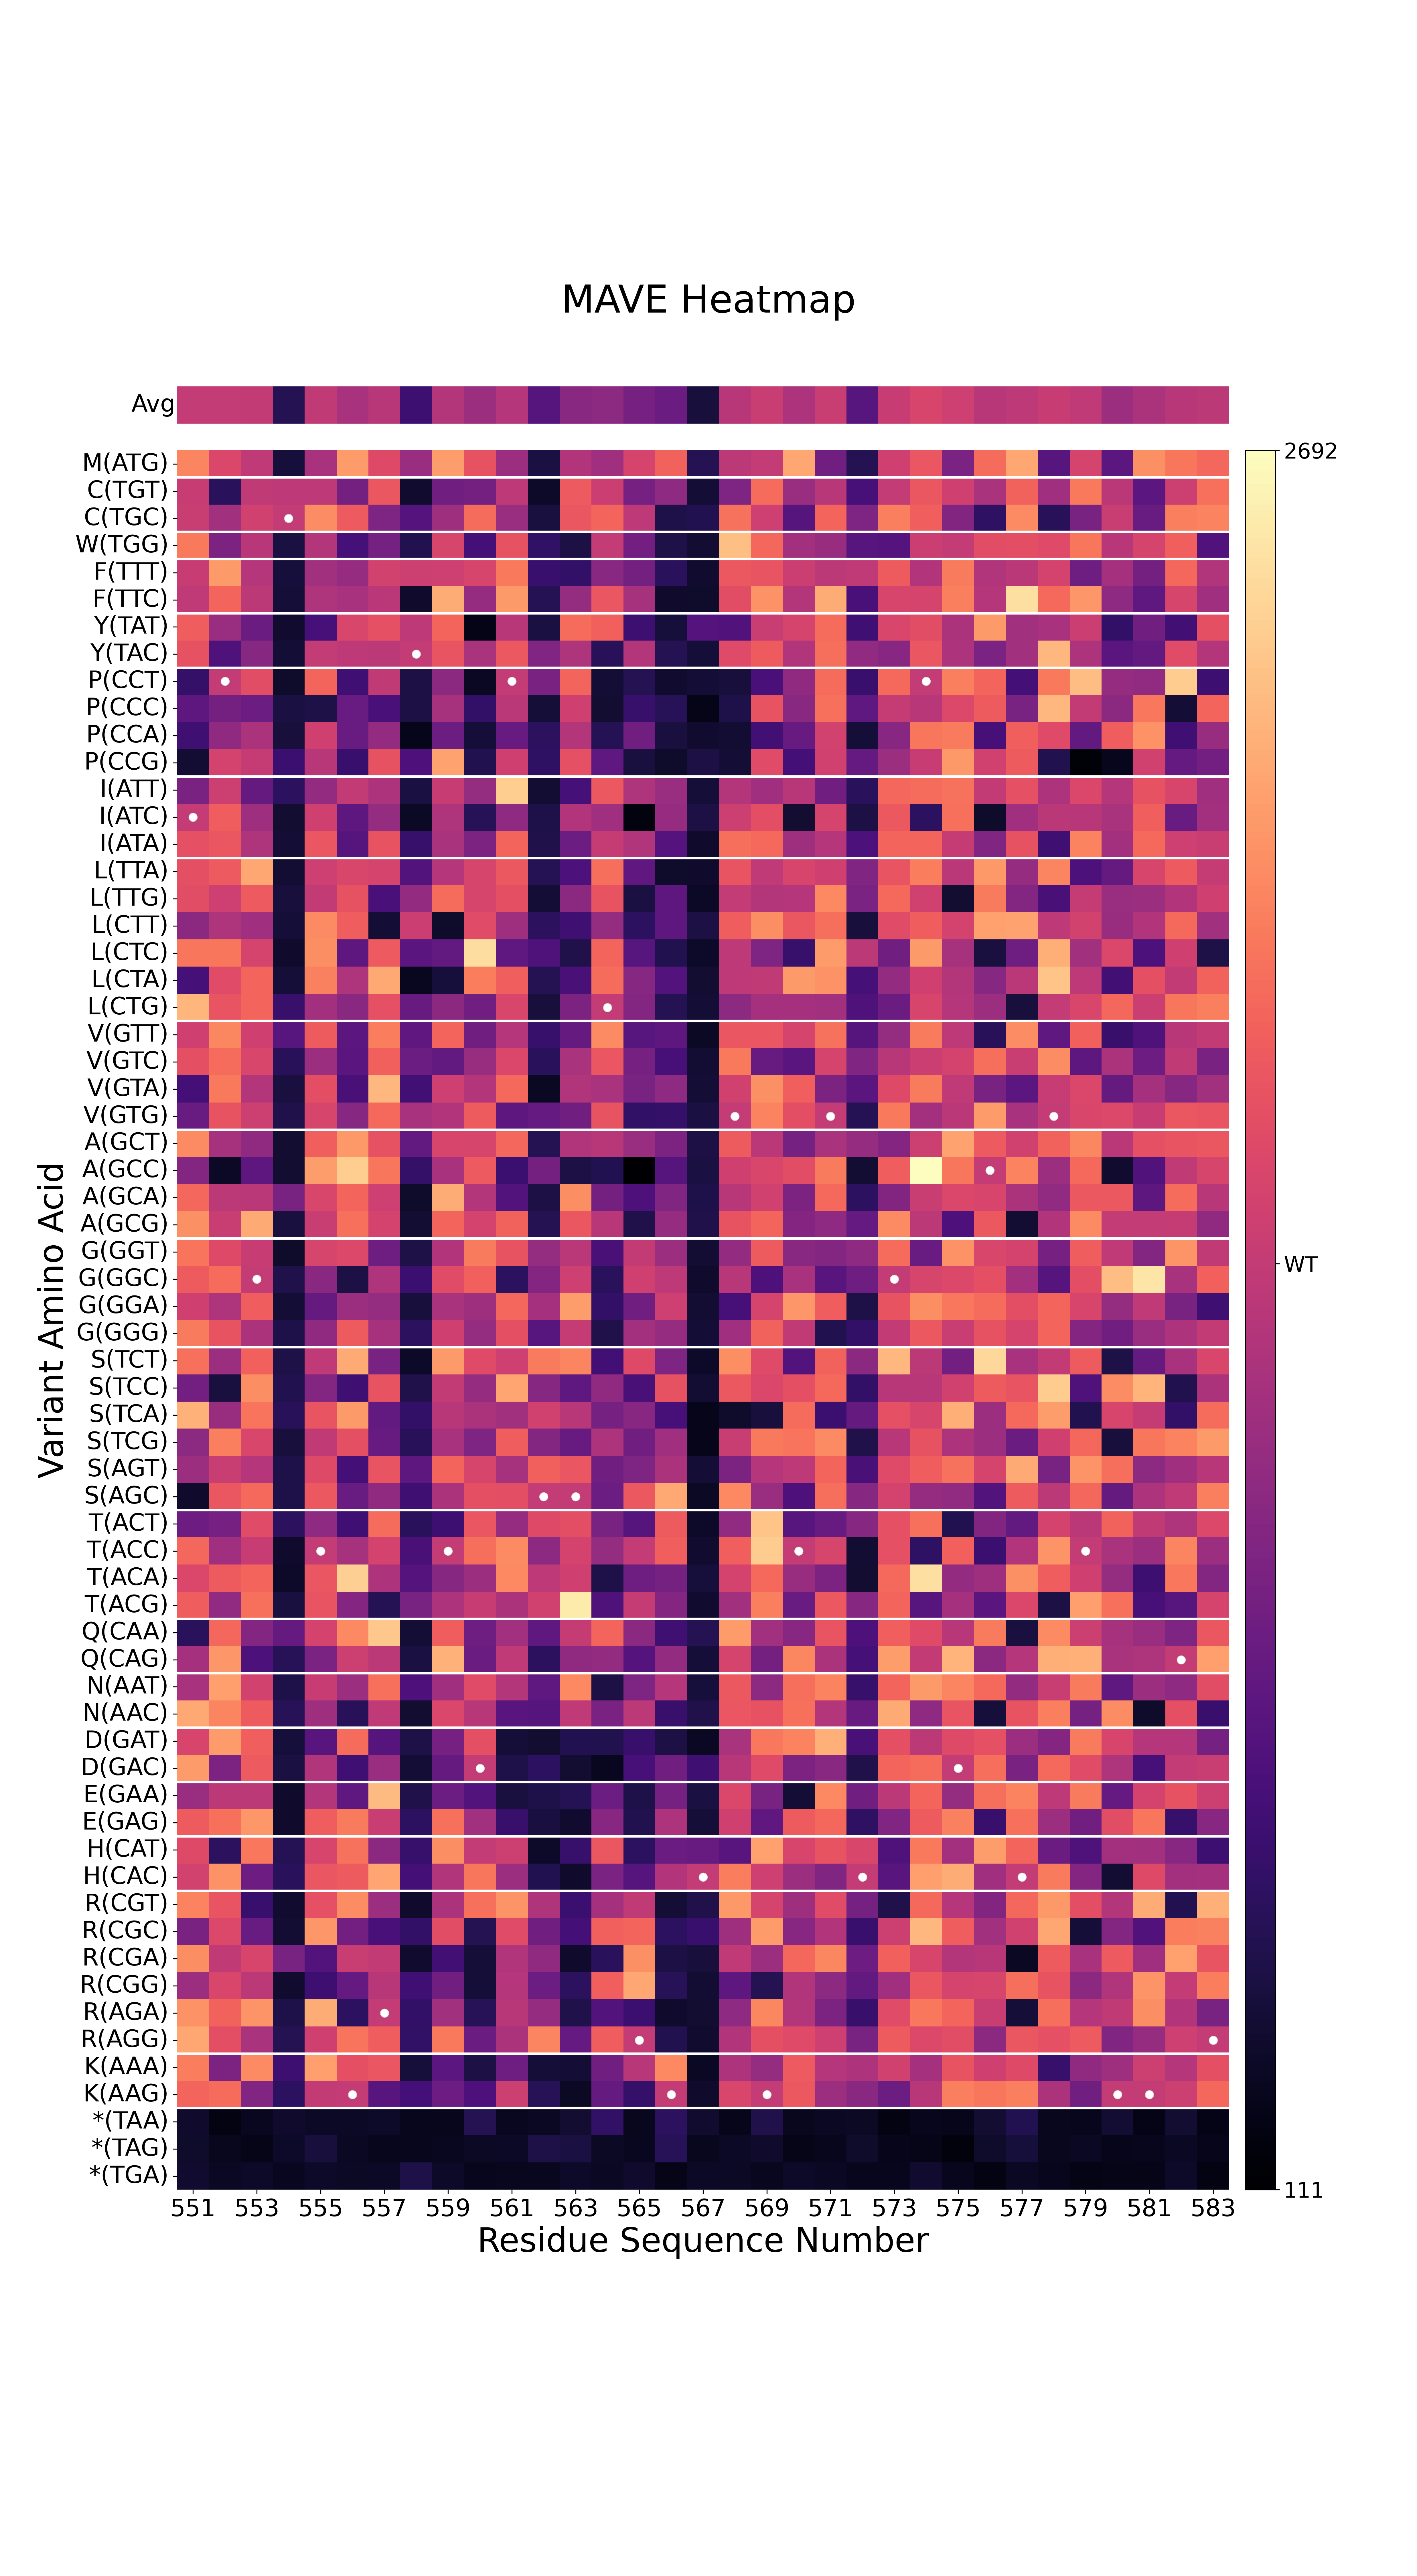

### Tile amino-acid heatmap (`test_multitile_regression_tile2_aa_heatmap_20260305.png`)

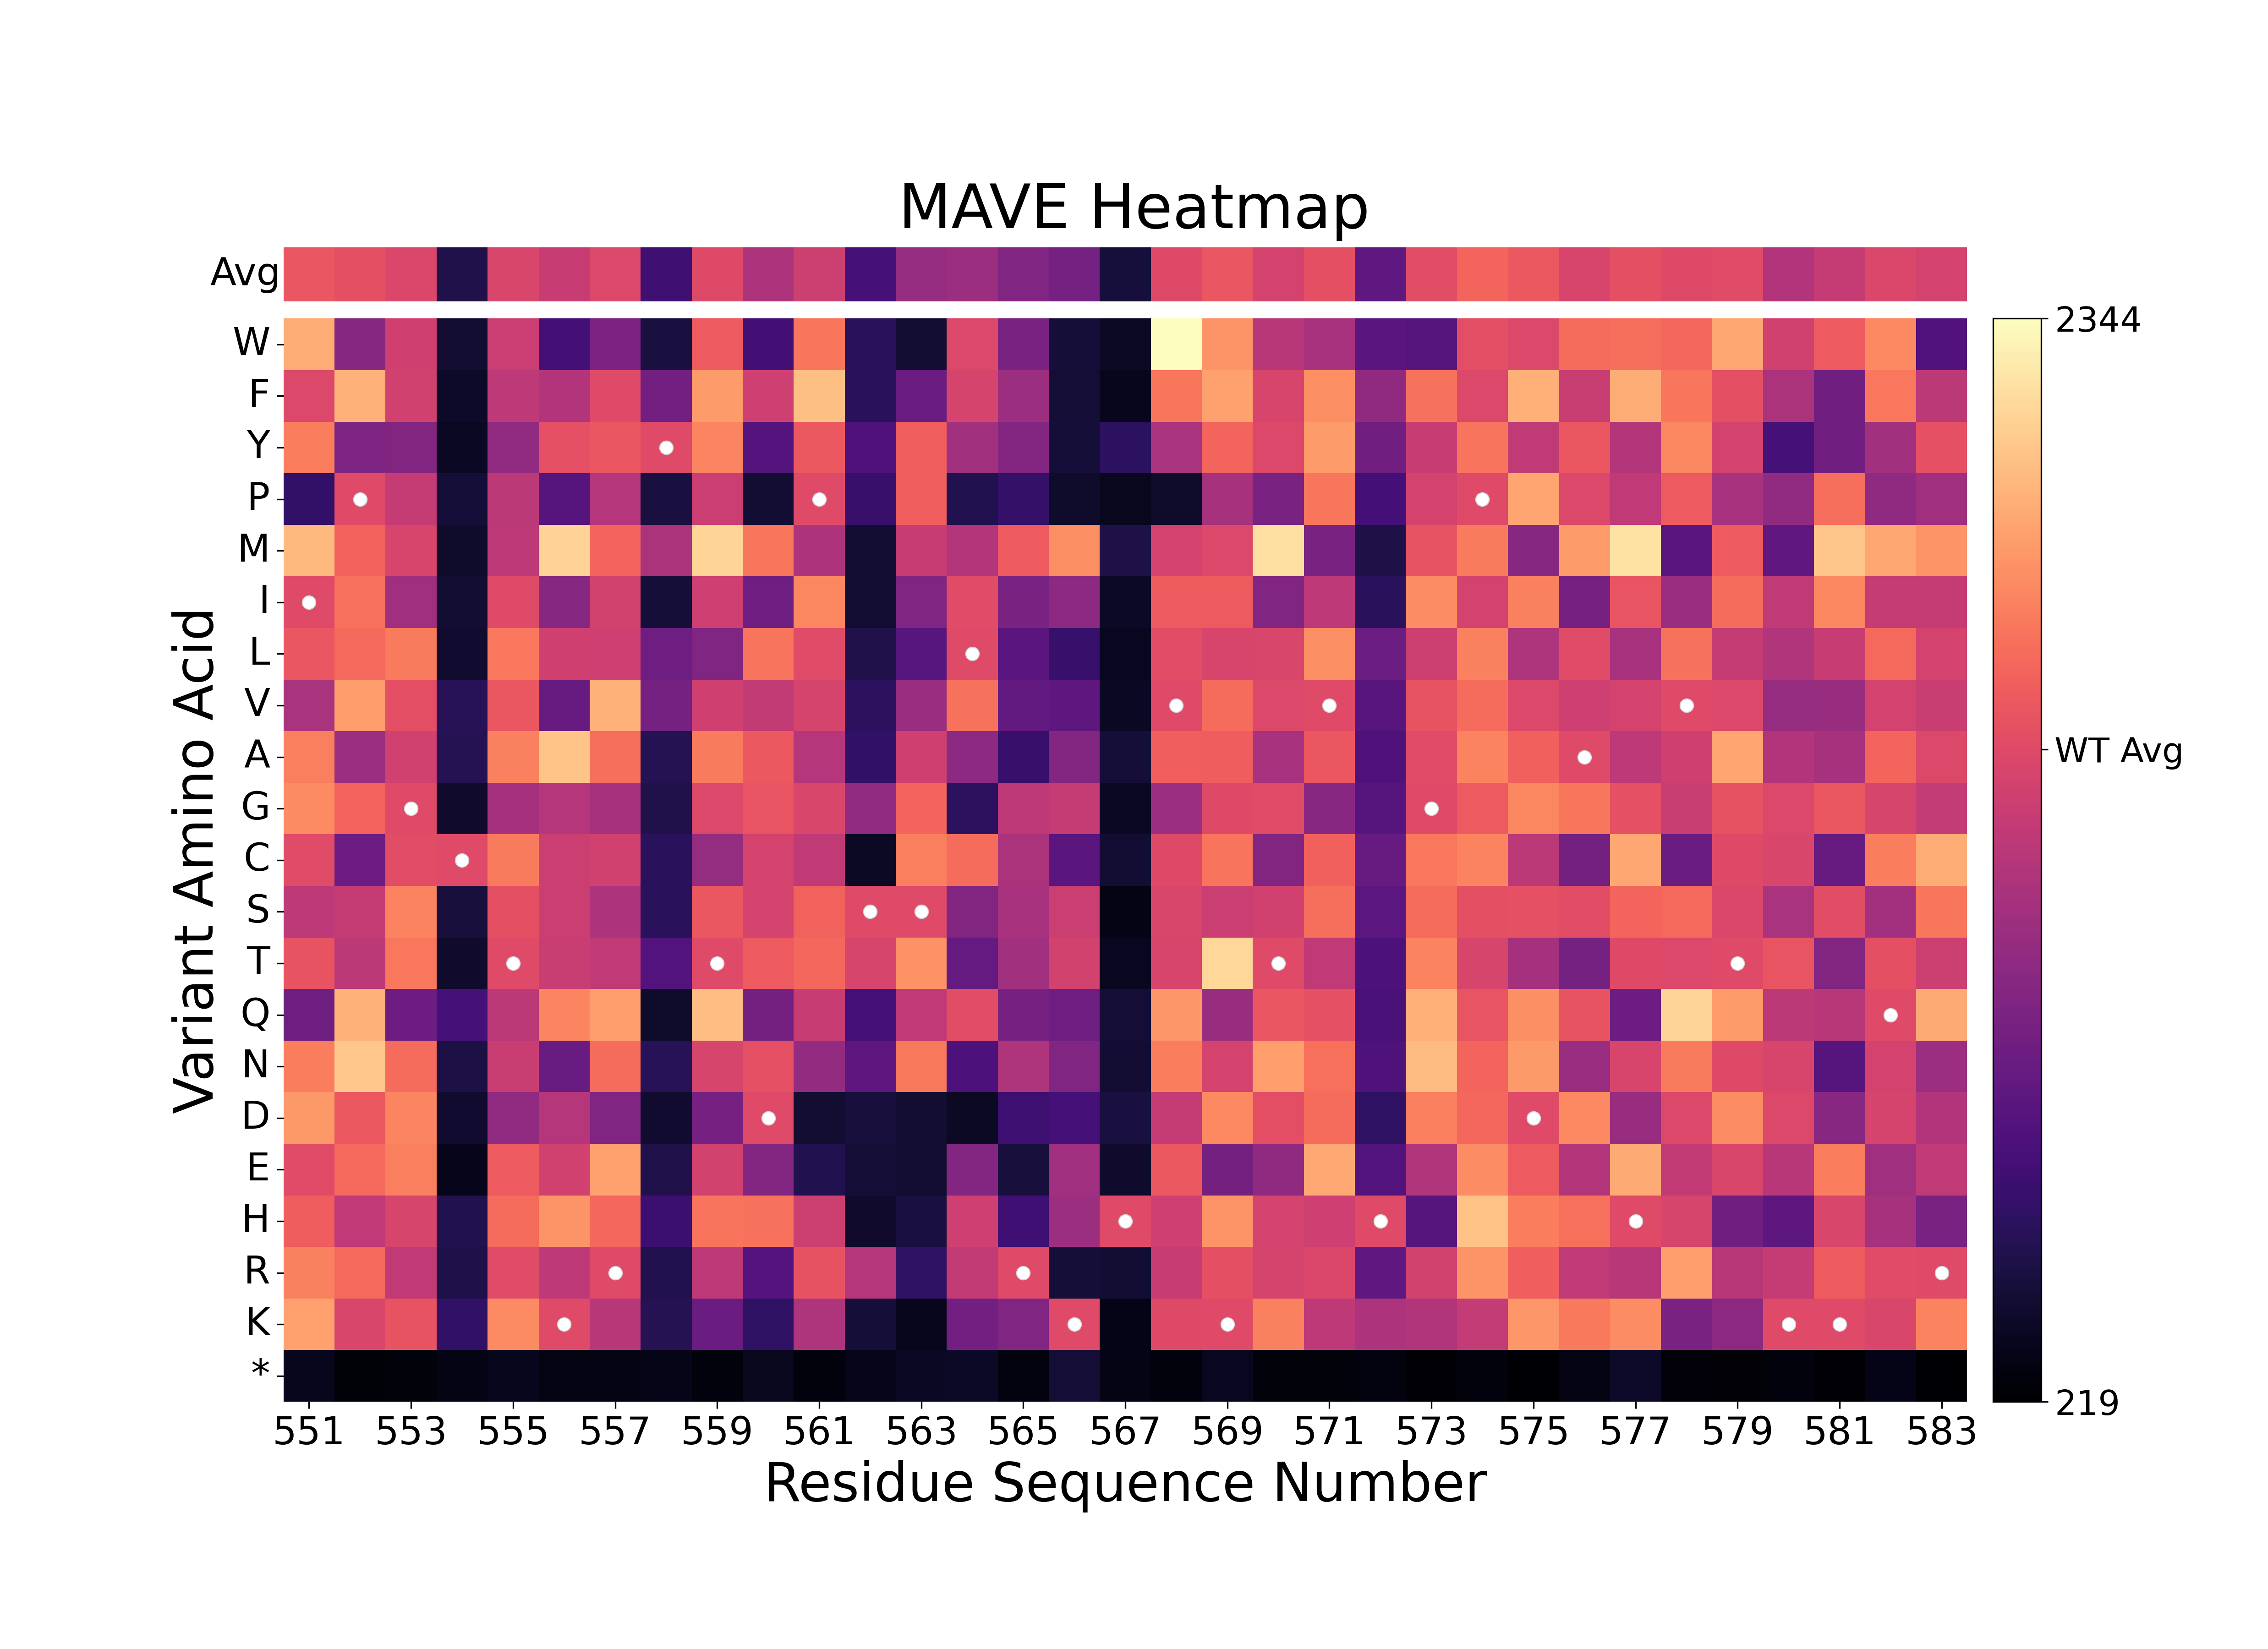

### Batch tiled heatmap (`tiled_heatmap_batch_zscore_2pole_20260305.png`)

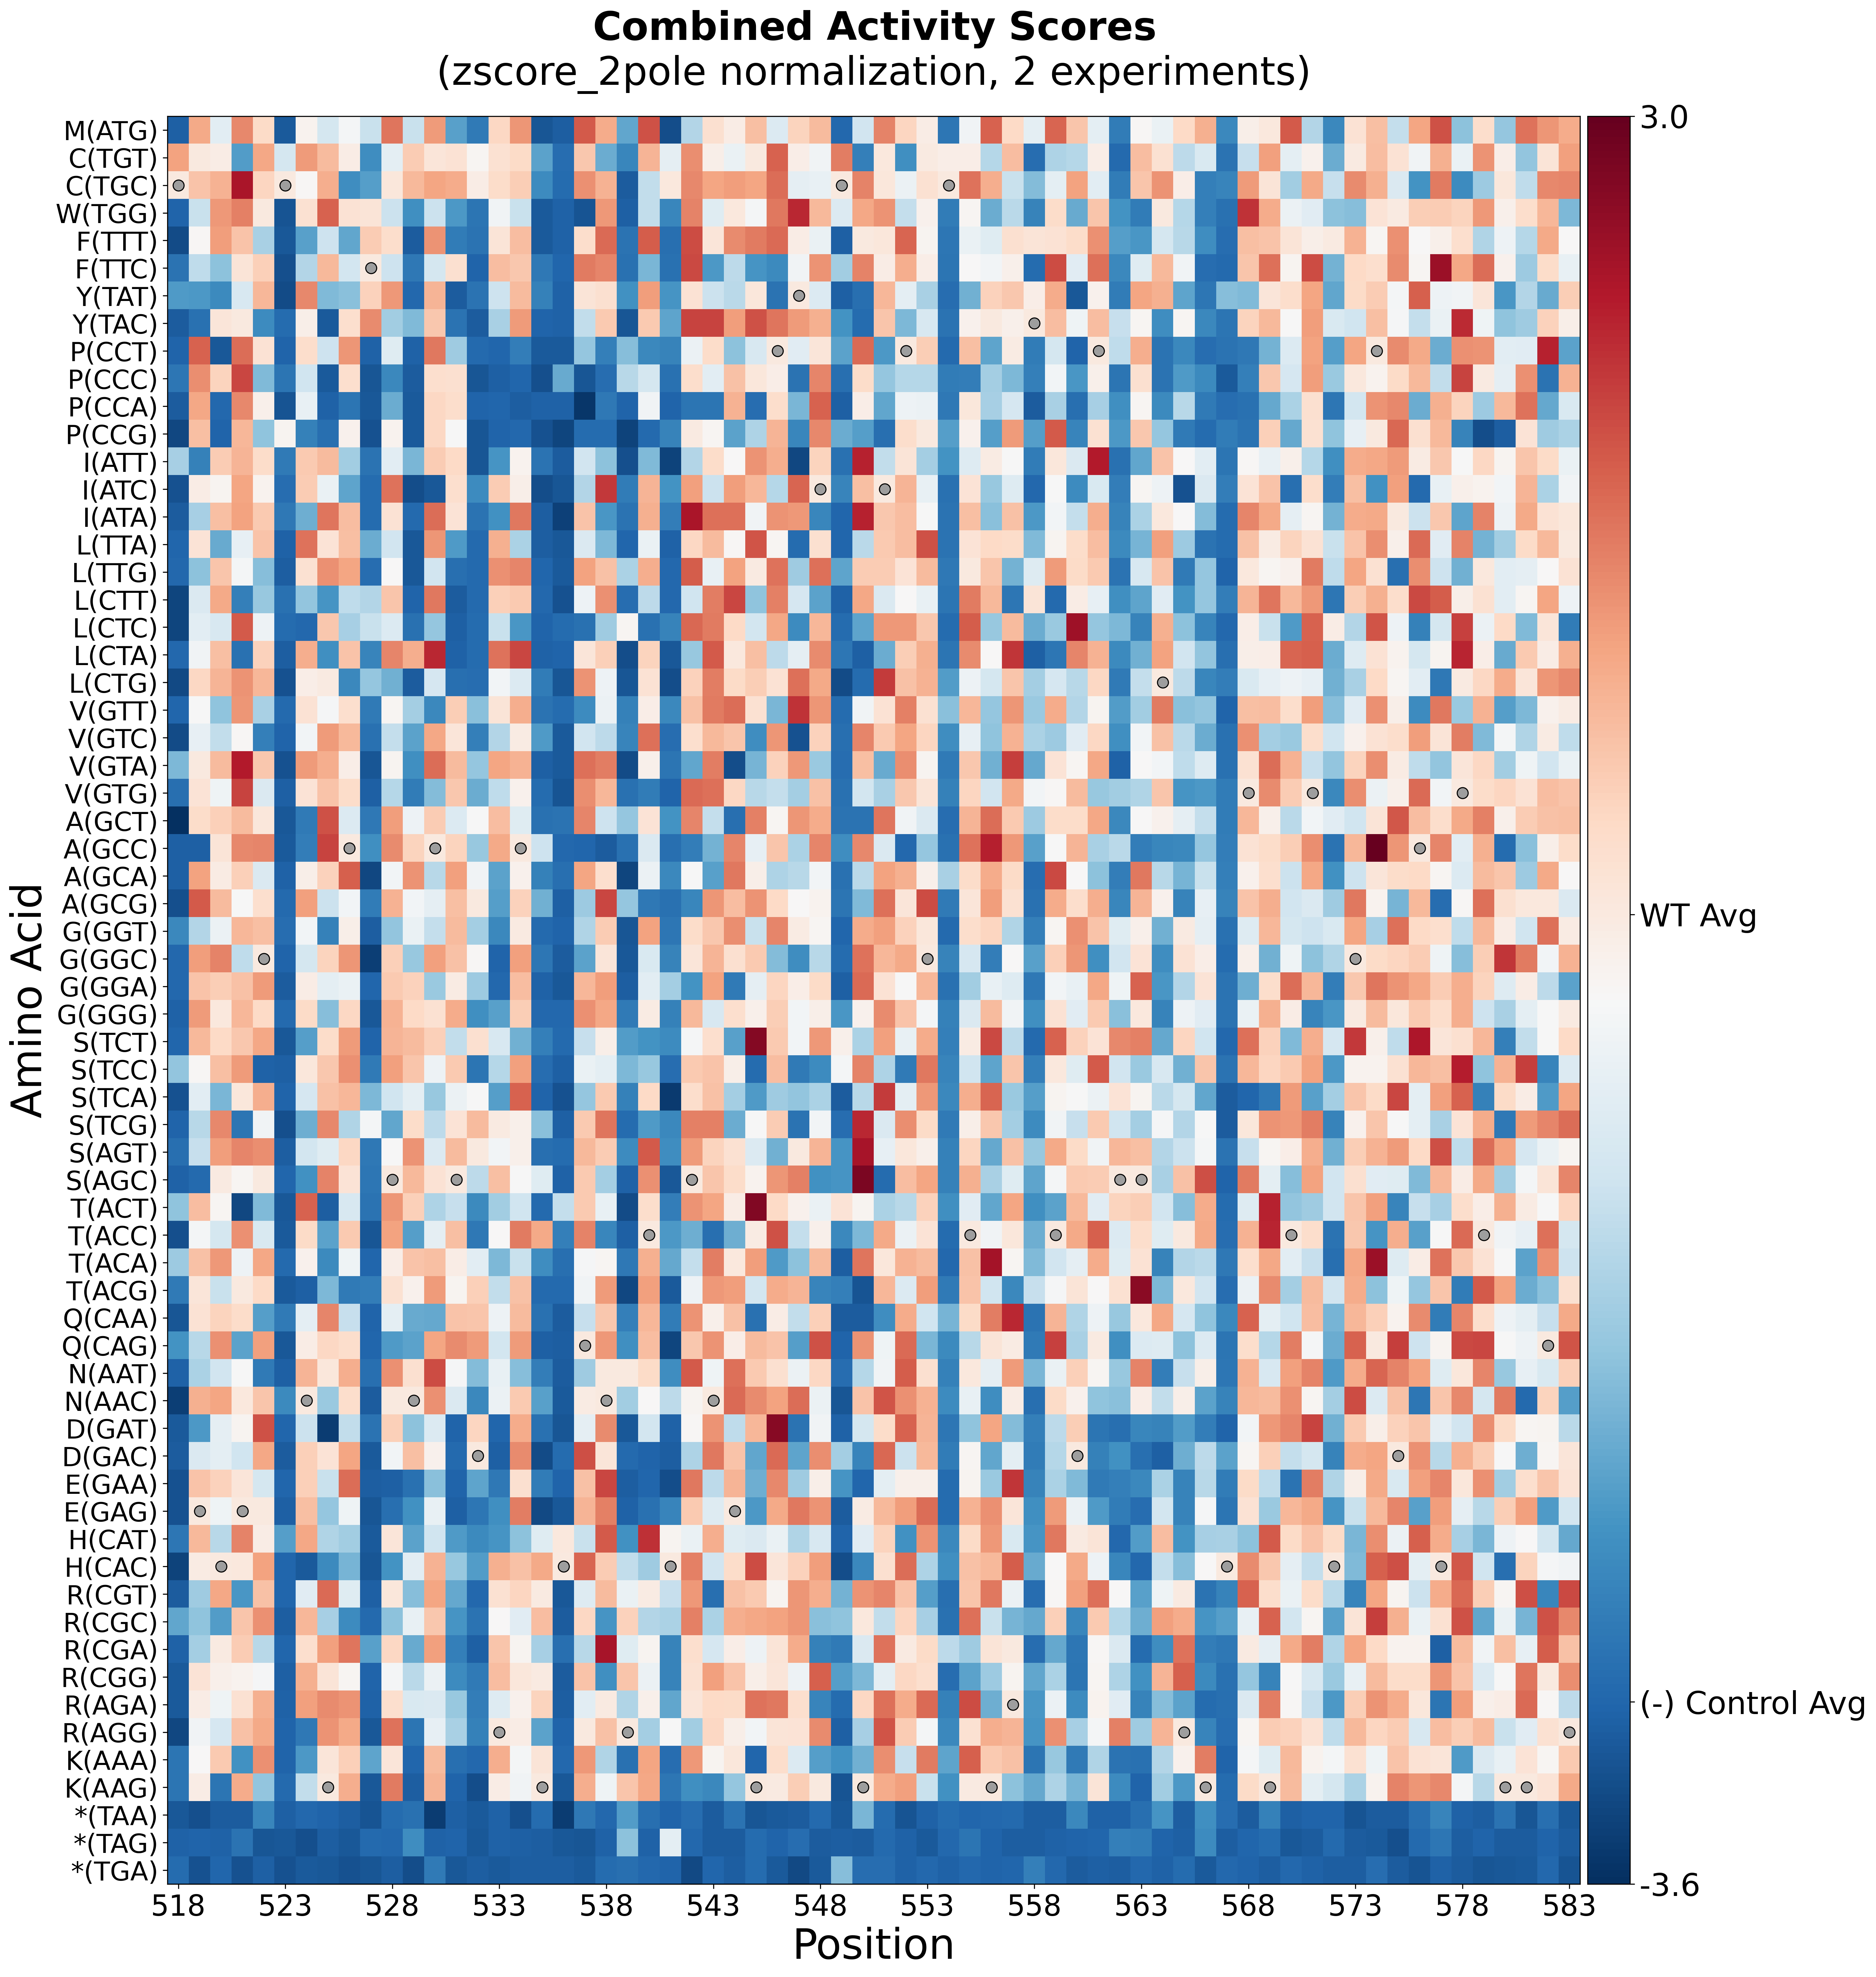

### Batch combined AA heatmap (`combined_aa_heatmap_batch_zscore_2pole_20260305.png`)

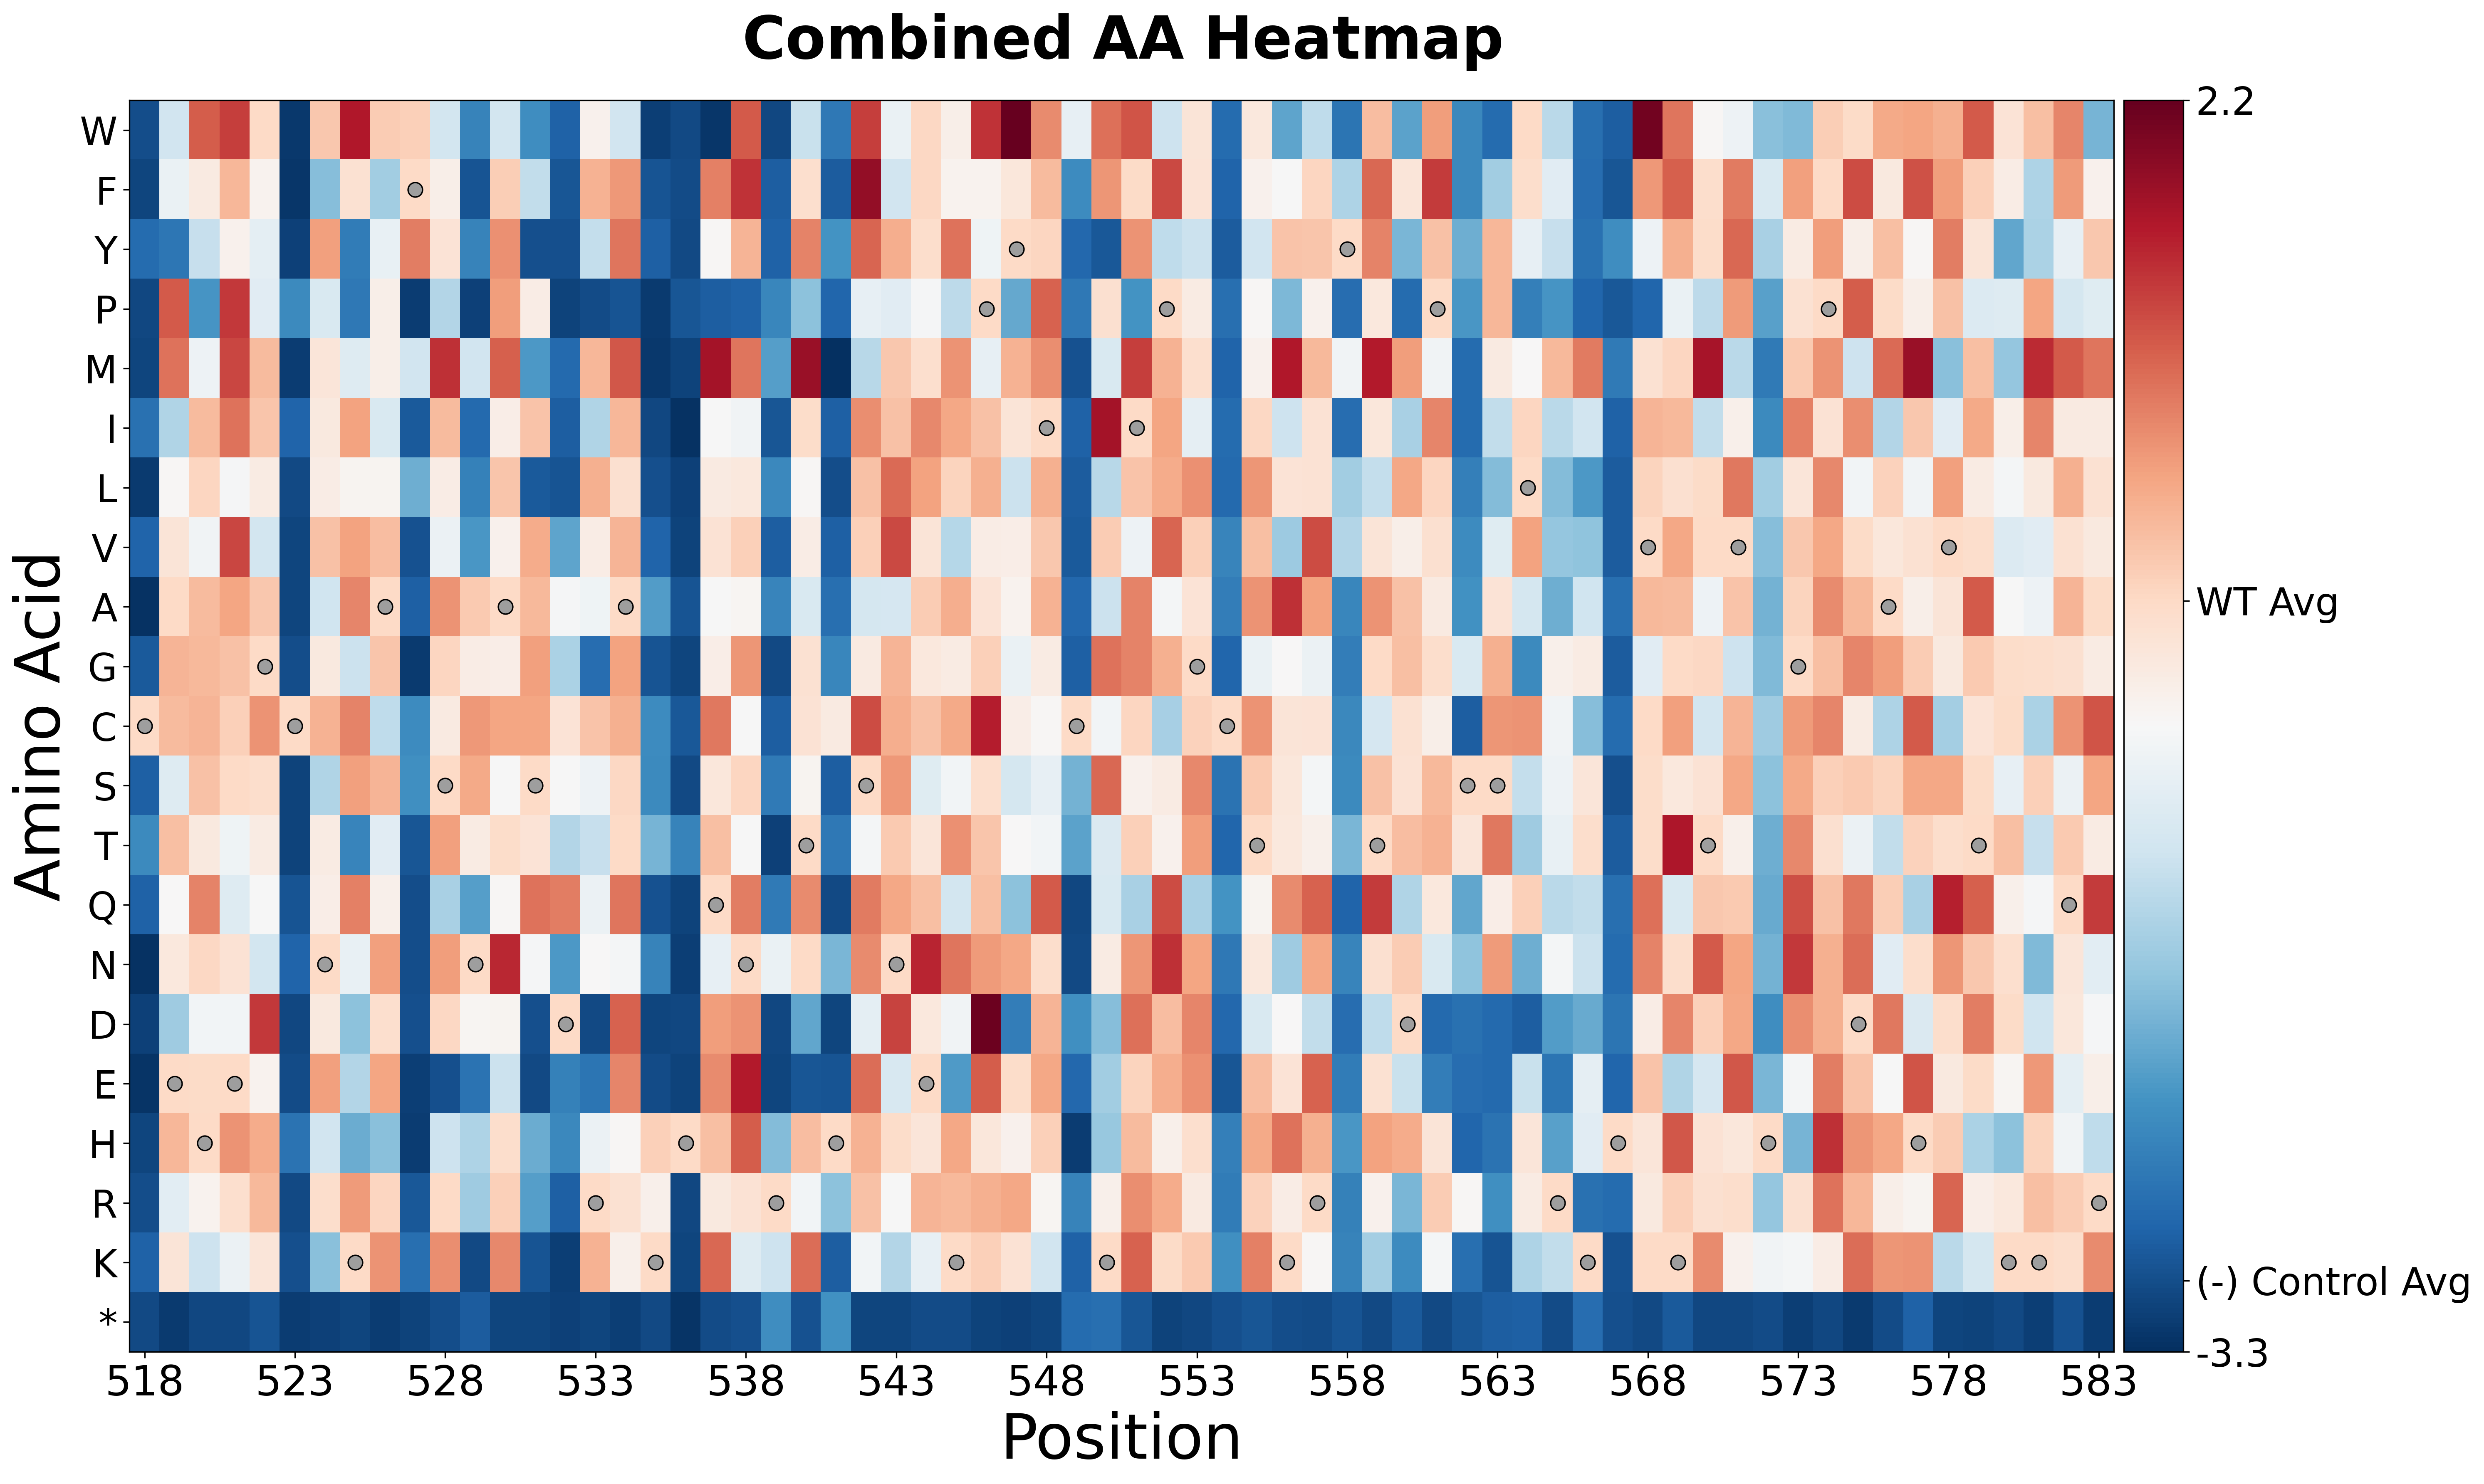

In [9]:
if codon_heatmap_file is None:
    print("No codon heatmap image found for this tile.")
else:
    display(Markdown(f"### Tile codon heatmap (`{codon_heatmap_file.name}`)"))
    display(Image(filename=str(codon_heatmap_file)))

if aa_heatmap_file is None:
    print("No amino-acid heatmap image found for this tile.")
else:
    display(Markdown(f"### Tile amino-acid heatmap (`{aa_heatmap_file.name}`)"))
    display(Image(filename=str(aa_heatmap_file)))

if tiled_heatmap_file is None:
    print("No tiled batch heatmap image found in combined output.")
else:
    display(Markdown(f"### Batch tiled heatmap (`{tiled_heatmap_file.name}`)"))
    display(Image(filename=str(tiled_heatmap_file)))

if combined_aa_heatmap_file is None:
    print("No combined AA batch heatmap image found in combined output.")
else:
    display(Markdown(f"### Batch combined AA heatmap (`{combined_aa_heatmap_file.name}`)"))
    display(Image(filename=str(combined_aa_heatmap_file)))
